In [1]:
import pandas as pd
import perf

In [2]:
# uint64_t load(const uint64_t* p) { return *p; }           // mov rax, [rdi]
# void store(uint64_t* p, uint64_t value) { *p = value; }   // mov [rdi], rsi

In [3]:
hot  = perf.benchmark(code="mov rax, [rdi]", mode=["latency"], event=["cycles"], config={"dcache":"hot", "icache": "hot", "dtlb": "hot", "itlb": "hot"}, name="hot")
hot

config.backend.loop.probes  config.backend.loop.runs  \
file name mode                                                            
NaN  hot  latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
...                                       ...                       ...   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   

                   config.backend.loop.target config.branch config.dcache  \
file name mode                                                              
NaN  hot  latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
...                                       ...           ...           ...   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   

                  config.dtlb config.icache config.itlb  data.0x4100003000  \
file name mode                                                               
NaN  hot  latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
...                       ...           ...         ...                ...   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   

                   iterations  samples  operations  cycles  
file name mode                                              
NaN  hot  latency       14699        0           1     1.0  
          latency       14699        1           1     1.0  
          latency       14699        2           1     1.0  
          latency       14699        3           1     1.0  
          latency       14699        4           1     1.0  
...                       ...      ...         ...     ...  
          latency       15271       95           1     1.0  
          latency       15271       96           1     1.0  
          latency       15271       97           1     1.0  
          latency       15271       98           1     1.0  
          latency       15271       99           1     1.0  

[200 rows x 13 columns]

In [4]:
cold = perf.benchmark(code="mov rax, [rdi]", mode=["latency"], event=["cycles"], config={"dcache":["hot","warm","cool","cold"], "icache": "hot", "dtlb": "hot", "itlb": "hot"}, name="cold")
cold

config.backend.loop.probes  config.backend.loop.runs  \
file name mode                                                            
NaN  cold latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
...                                       ...                       ...   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   
          latency                           3                        10   

                   config.backend.loop.target config.branch config.dcache  \
file name mode                                                              
NaN  cold latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
          latency                       0.005   predictable           hot   
...                                       ...           ...           ...   
          latency                       0.005   predictable          cold   
          latency                       0.005   predictable          cold   
          latency                       0.005   predictable          cold   
          latency                       0.005   predictable          cold   
          latency                       0.005   predictable          cold   

                  config.dtlb config.icache config.itlb  data.0x4100003000  \
file name mode                                                               
NaN  cold latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
...                       ...           ...         ...                ...   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   
          latency         hot           hot         hot                  0   

                   iterations  samples  operations  cycles  
file name mode                                              
NaN  cold latency       24584        0           1     1.0  
          latency       24584        1           1     1.0  
          latency       24584        2           1     1.0  
          latency       24584        3           1     1.0  
          latency       24584        4           1     1.0  
...                       ...      ...         ...     ...  
          latency        2305       95           1   277.0  
          latency        2305       96           1   276.0  
          latency        2305       97           1   278.0  
          latency        2305       98           1   278.0  
          latency        2305       99           1   277.0  

[800 rows x 13 columns]

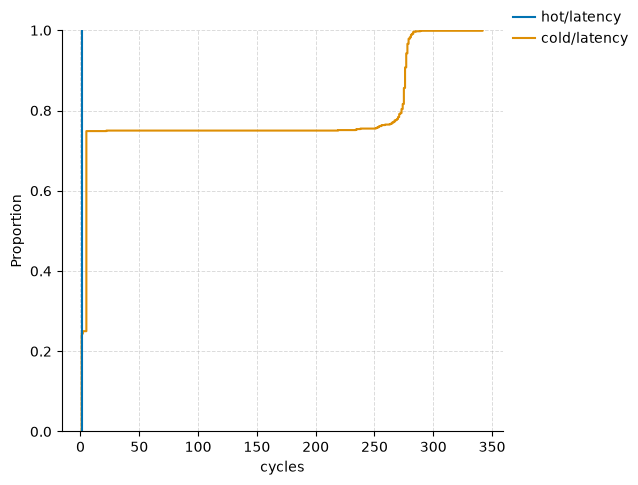

[]

In [5]:
df = pd.concat([hot, cold])
perf.plot(df, "ecdf", event=["cycles"])